In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
from tqdm import tqdm
from utils import plot_3d_trajectory, plot_observations
from utils import solve_lorenz
from utils import evaluate
from utils import plot_estim_evolution
from utils import sgd_update
from utils import compute_snr
import optuna
import mlflow
from optuna.integration.mlflow import MLflowCallback

In [2]:
import configparser

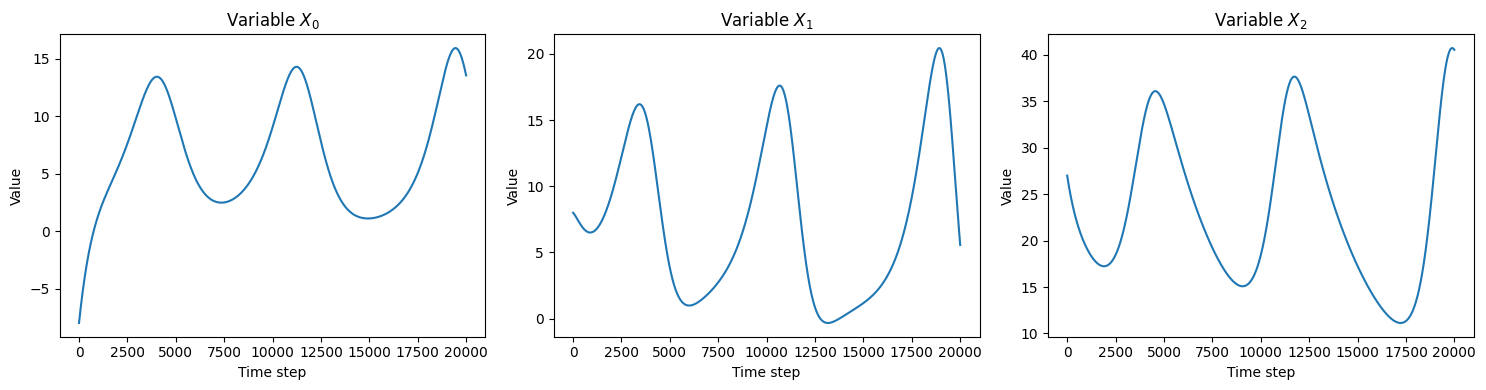

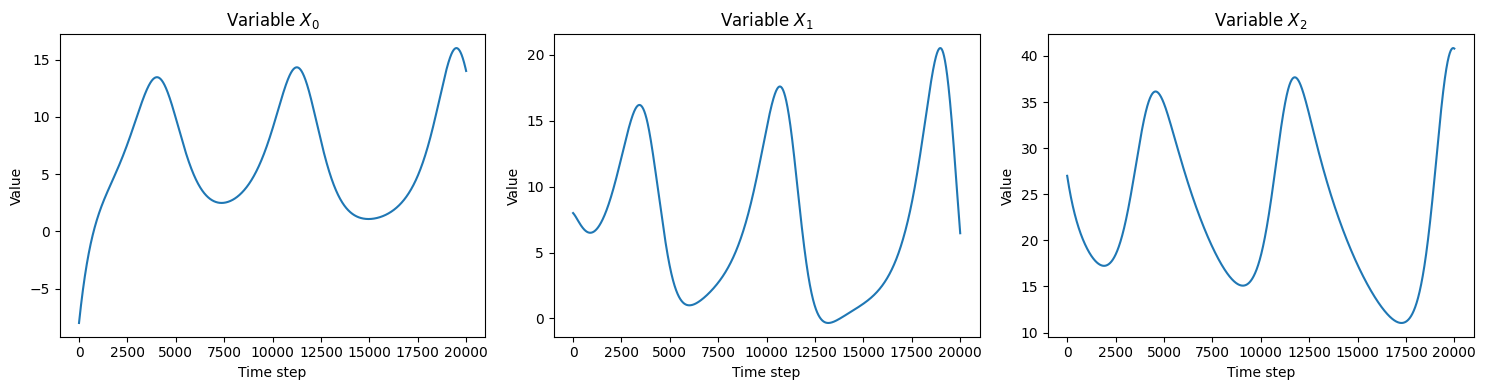

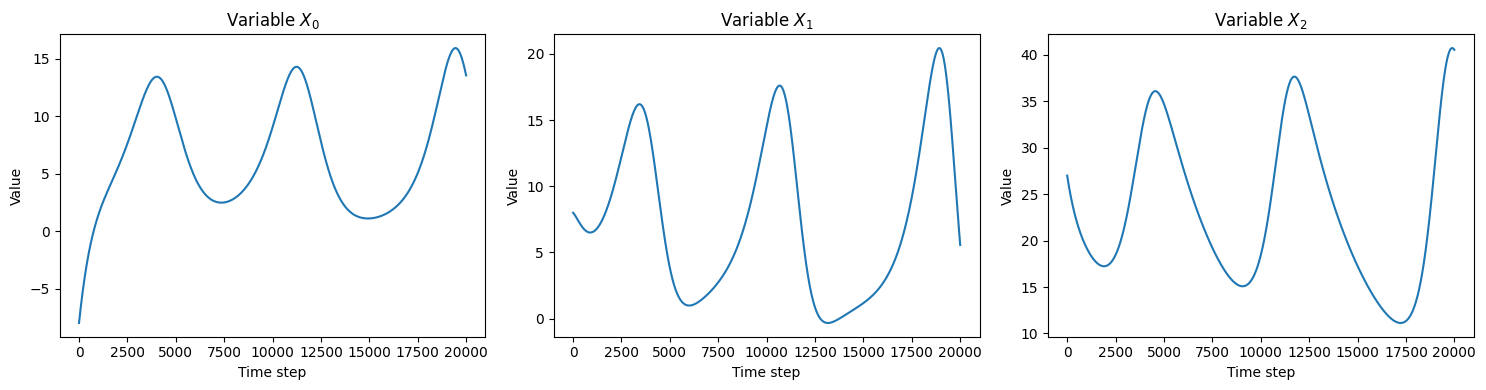

In [3]:
def f(X, theta):
    return np.array([
        theta[0]*X[1] - theta[0]*X[0],
        theta[1]*X[0] - X[0]*X[2] - X[1],
        X[0]*X[1] - theta[2]*X[2]
    ])

def runge_kutta4(f, X_n, theta, h):
    k1 = f(X_n, theta)
    k2 = f(X_n + h*k1/2, theta)
    k3 = f(X_n + h*k2/2, theta)
    k4 = f(X_n + h*k3, theta)
    return X_n + h*(k1 + 2*k2 + 2*k3 + k4)/6

def rk45(f, X_0, theta, t_0, t_f, h):
    """
    Runge-Kutta 4th/5th order (Cash-Karp) method
    without scipy
    """
    N = int((t_f - t_0) / h)
    observations = np.zeros((N, 3))
    observations[0] = X_0
    
    # Cash-Karp coefficients
    c = np.array([0, 1/5, 3/10, 3/5, 1, 7/8])
    a = np.array([
        [0, 0, 0, 0, 0],
        [1/5, 0, 0, 0, 0],
        [3/40, 9/40, 0, 0, 0],
        [3/10, -9/10, 6/5, 0, 0],
        [-11/54, 5/2, -70/27, 35/27, 0],
        [1631/55296, 175/512, 575/13824, 44275/110592, 253/4096]
    ])
    
    b4 = np.array([37/378, 0, 250/621, 125/594, 0, 512/1771])
    b5 = np.array([2825/27648, 0, 18575/48384, 13525/55296, 277/14336, 1/4])
    
    X_n = X_0.copy()
    for n in range(N-1):
        k = np.zeros((6, 3))
        
        # Compute stages
        k[0] = f(X_n, theta)
        k[1] = f(X_n + h*a[1, 0]*k[0], theta)
        k[2] = f(X_n + h*(a[2, 0]*k[0] + a[2, 1]*k[1]), theta)
        k[3] = f(X_n + h*(a[3, 0]*k[0] + a[3, 1]*k[1] + a[3, 2]*k[2]), theta)
        k[4] = f(X_n + h*(a[4, 0]*k[0] + a[4, 1]*k[1] + a[4, 2]*k[2] + a[4, 3]*k[3]), theta)
        k[5] = f(X_n + h*(a[5, 0]*k[0] + a[5, 1]*k[1] + a[5, 2]*k[2] + a[5, 3]*k[3] + a[5, 4]*k[4]), theta)
        
        # Compute 4th and 5th order estimates
        X_4 = X_n + h * np.sum(b4[:, None] * k, axis=0)
        X_5 = X_n + h * np.sum(b5[:, None] * k, axis=0)
        
        # Use 5th order result
        X_n = X_5
        observations[n+1] = X_n
    
    return observations

X_0 = np.array([-8.0, 8.0, 27.0], dtype=np.float64)
theta = np.array([10.0, 28.0, 8.0/3.0], dtype=np.float64)
t_0, t_f = 0, 2
h = 1e-4
N = int((t_f-t_0)/h)

observations = np.zeros((N, 3))
observations[0] = np.array(X_0)
for n in range(N-1):
    observations[n+1] = runge_kutta4(f, observations[n], theta, h)

observations_solver = solve_lorenz(t_0=t_0, t_f=t_f, dt=h, X_0=X_0)
observations_rk45 = rk45(f, X_0, theta, t_0, t_f, h)

plot_observations(observations)
plot_observations(observations_solver)
plot_observations(observations_rk45)

In [4]:
mean_abs_diff = np.abs(observations_solver - observations).mean()
mean_abs_diff_rk45 = np.abs(observations_solver - observations_rk45).mean()
mean_abs_diff_rk4_rk45 = np.abs(observations - observations_rk45).mean()

print(f"Mean absolute difference between solver and RK4: {mean_abs_diff:.14f}")
print(f"Mean absolute difference between solver and RK45: {mean_abs_diff_rk45:.14f}")
print(f"Mean absolute difference between RK4 and RK45: {mean_abs_diff_rk4_rk45:.14f}")

Mean absolute difference between solver and RK4: 0.10863339971239
Mean absolute difference between solver and RK45: 0.10863339971227
Mean absolute difference between RK4 and RK45: 0.00000000000028


In [5]:
def compute_grad(f, methode, theta_estim, A, estim_obs, n):
    sum_term = np.dot(estim_obs[:n], A).sum(axis=0)   

    X_nm1 = estim_obs[n-1]
    X_n   = estim_obs[n] 
    
    error = methode(f, X_nm1, theta_estim, h) -  X_n
    # error = h * f(X_nm1, theta_estim) + X_nm1 -  X_n

    grad = sum_term * error
    return grad

In [6]:
def plot_grads(grads, var_names=None):
    var_names = [r'$\frac{\partial X_0}{\partial t}$',
                 r'$\frac{\partial X_1}{\partial t}$', 
                 r'$\frac{\partial X_2}{\partial t}$']

    time = np.arange(grads.shape[0])
    plt.figure(figsize=(15, 4))

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.plot(time, grads[:, i])
        plt.title(var_names[i])
        plt.xlabel('Time step')
        plt.ylabel('Value')
    
    plt.tight_layout()
    plt.show()

In [7]:
def decay_lr(lr, epoch, decay = 1e-4): 
    return lr

In [8]:
def decay_grad(grads, current_grad_idx, clip_value=np.array([25,10,10]), window=40, decay=0.8):

    grad = grads[current_grad_idx]

    # --- soft clipping ---
    grad = clip_value * np.tanh(grad / clip_value)
    grads[current_grad_idx] = grad

    # --- window selection ---
    start = max(0, current_grad_idx - window + 1)
    window_grads = grads[start:current_grad_idx + 1]

    # --- exponential decay weights ---
    n = len(window_grads)
    weights = decay ** np.arange(n)[::-1]
    weights = weights / np.sum(weights)

    # --- weighted average ---
    smoothed_grad = np.sum(window_grads * weights[:, None], axis=0)

    # grad_norm = smoothed_grad / (np.linalg.norm(smoothed_grad) + 1e-8)

    return smoothed_grad

In [9]:
def decay_grad(grads, current_grad_idx, clip_value=np.array([25,10,10]), window=40, decay=0.8):

    grad = grads[current_grad_idx]

    # --- window selection ---
    start = max(0, current_grad_idx - window + 1)
    window_grads = grads[start:current_grad_idx + 1]

    # --- normalize each gradient BEFORE smoothing ---
    norms = np.linalg.norm(window_grads, axis=1, keepdims=True) + 1e-8
    window_grads_norm = window_grads / norms


    # --- weighted average of normalized grads ---
    smoothed_grad = np.sum(window_grads_norm, axis=0)

    return smoothed_grad


In [10]:
def l_estimators(window_grads, trim_ratio=0.2):

    x = np.sort(window_grads)
    n = len(x)

    # 1. Mean
    mean_est = np.sum(window_grads,  axis=0)

    # 2. Median
    median_est = np.median(window_grads, axis=0) * n

    # 3. Trimmed mean
    k = int(trim_ratio * n)
    trimmed = x[k:n-k] if n > 2*k else x
    trimmed_mean = np.mean(trimmed, axis=0)

    # 4. Winsorized mean
    winsor = x.copy()
    if n > 2*k:
        winsor[:k] = x[k]
        winsor[n-k:] = x[n-k-1]
    winsor_mean = np.mean(winsor,  axis=0)

    return {
        "mean": mean_est,
        "median": median_est,
        "trimmed_mean": trimmed_mean,
        "winsor_mean": winsor_mean
    }

In [11]:
def decay_grad(grads, current_grad_idx, clip_value=np.array([25,10,10]), window=40, decay=0.8, l_estim = "mean"):

    grad = grads[current_grad_idx]
    grads[current_grad_idx] = grad

    start = max(0, current_grad_idx - window + 1)
    window_grads = grads[start:current_grad_idx + 1]

    # --- normalize each gradient BEFORE smoothing ---
    norms = np.linalg.norm(window_grads, axis=1, keepdims=True) + 1e-8
    window_grads_norm = window_grads / norms

    # compute L-estimators
    estimates = l_estimators(window_grads_norm)

    return estimates[l_estim]

In [12]:
def main(window = 40, 
         decay = 0.8, 
         epochs = 2,
         std = 0.01,
         noise_level=0.5,
         lr = np.array([1e-3, 1e-3, 1e-3]), 
         clip_value = np.array([25,10,10]),
         l_estim = "mean"): 
    
    theta_estim = np.array([-5.0, -3.0, 8.0])

    nbr_epochs = int(epochs * N)
    A = np.array([[-1, 1, 0],
                [1 , 0, 0],
                [0 , 0, -1]])

    estim_obs = observations.copy() + noise_level*np.random.normal(0, std, (N, 3))

    theta_estim_vec = np.zeros((nbr_epochs, 3))
    theta_estim_vec[0] = theta_estim

    grads = np.zeros((nbr_epochs, 3))
    gra = np.zeros((nbr_epochs, 3))

    for epoch in tqdm(range(1, nbr_epochs)):
        n = epoch % N
        grad = compute_grad(f, runge_kutta4, theta_estim, A, estim_obs, n)
        grads[epoch, :] = grad
        grad = decay_grad(grads, epoch, clip_value, window, decay, l_estim)
        gra[epoch, :] = grad
        theta_estim = sgd_update(theta_estim, grad, lr)
        lr = decay_lr(lr, epoch)
        theta_estim_vec[epoch] = theta_estim
    
    return theta_estim, theta_estim_vec, grads, gra

In [33]:
config = configparser.ConfigParser()
config.read('config.ini')
param_snr = 'Params_var_001'
std = config[param_snr].getfloat('var')
noise_level = config[param_snr].getfloat('noise_level')

snr = compute_snr(observations, noise_level, std)
print(f"SNR (dB) for each dimension: {snr}")
print(f"Average SNR (dB): {np.mean(snr):.2f}")

SNR (dB) for each dimension: [39.8263689  41.50271868 44.17775352]
Average SNR (dB): 41.84


In [ ]:
window = config[param_snr].getint('window')
decay = config[param_snr].getfloat('decay')
nbr_epochs = config[param_snr].getfloat('nbr_epochs')
lr_0 = config[param_snr].getfloat('lr_0')
lr_1 = config[param_snr].getfloat('lr_1')
lr_2 = config[param_snr].getfloat('lr_2')
clip_0 = config[param_snr].getfloat('clip_0')
clip_1 = config[param_snr].getfloat('clip_1')
clip_2 = config[param_snr].getfloat('clip_2')

In [41]:
theta_estim, theta_estim_vec, grads, gra = main(window, 
                                           decay, 
                                           nbr_epochs, 
                                           std,
                                           noise_level,
                                           np.array([lr_0, lr_1, lr_2]), 
                                           np.array([clip_0, clip_1, clip_2]))

  0%|          | 96/82835 [00:00<01:29, 927.38it/s]

100%|██████████| 82835/82835 [01:32<00:00, 896.32it/s] 


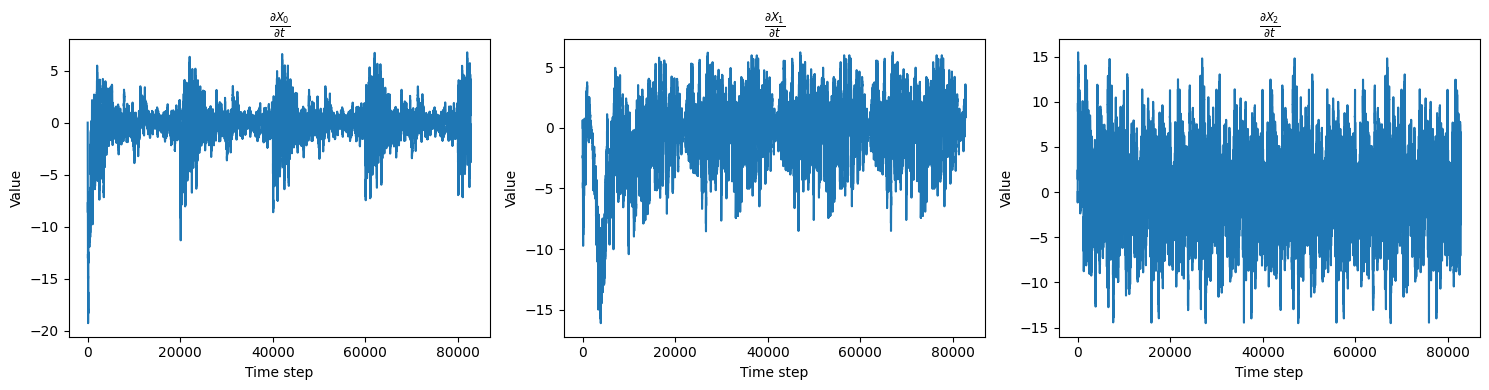

In [42]:
plot_grads(gra)

L'erreur relative sur σ, ρ, β est de : 16.390335%, 0.150210%, 24.375474%


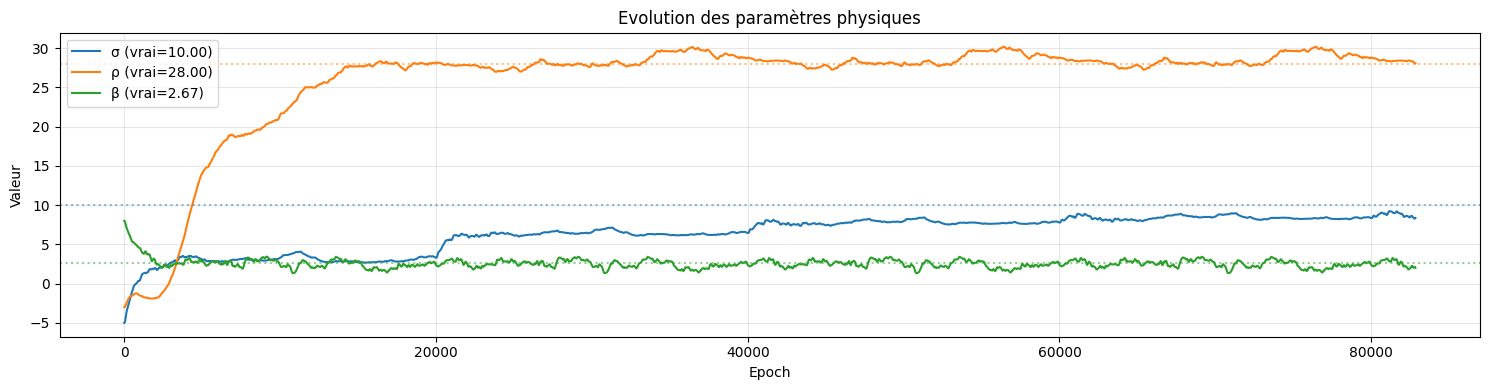

In [43]:
sigma, rho, beta = evaluate(theta_estim, theta)

plot_estim_evolution(theta_estim_vec, theta)

In [44]:
# https://github.com/scipy/scipy/blob/b2b7944064af15bd87e781216c2dfda7400ecd2d/scipy/integrate/_ivp/rk.py

In [45]:
# import numpy as np
# from scipy.integrate._ivp.rk import RK45

# # Initial condition
# X_0 = np.array([-8.0, 8.0, 27.0], dtype=np.float64)

# # Initial and final time
# t0 = 0.0
# t_bound = 10.0

# # Number of stored observations
# N = 50_000
# observations = np.zeros((N, 3))
# observations[0] = X_0

# # Create solver
# solver = RK45(lorenz, t0, X_0, t_bound,
#               rtol=1e-7, atol=1e-9,
#               max_step=np.inf)


# n = 0
# while solver.status == "running":
#     solver.step()
#     n += 1
#     observations[n] = solver.y
